In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [2]:
df = pd.read_csv('Леденцы.dat', sep=';') # считываем файл
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11
0,4,5,5,5,3,3,3,3,3,3,3
1,5,4,5,5,3,3,3,3,3,3,3
2,5,5,4,5,3,3,3,3,3,3,3
3,5,4,5,5,3,3,3,3,3,3,3
4,4,5,5,5,3,3,3,3,3,3,3


## Лабораторная работа 3

Для метода DBSCAN важны два параметра min_samples и eps. Усановим значение min_samples = 2 * количество признаков для устойчивости метода, а значение eps будем подбирать с помощью графика k-расстояний

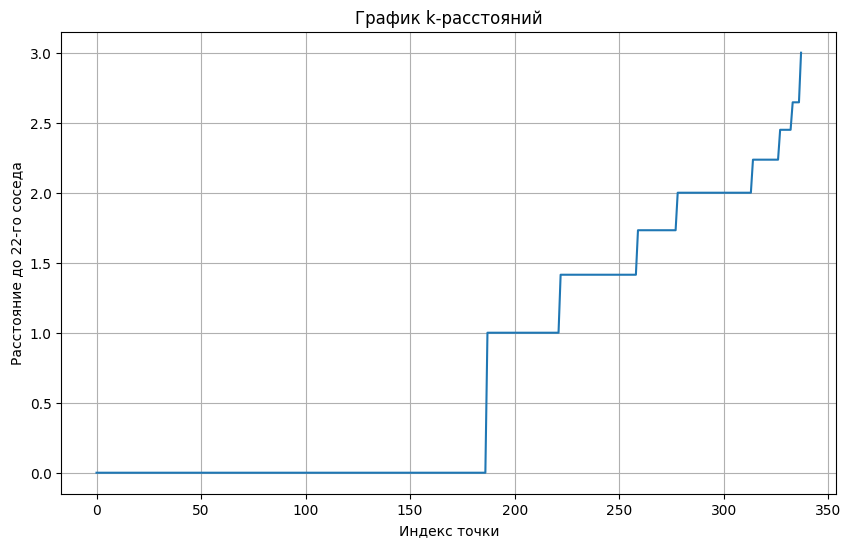

In [3]:
min_samples = 22
# Обучаем модель для поиска ближайших соседей
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(df)
distances, indices = neighbors_fit.kneighbors(df)

# Сортируем расстояния до k-го соседа
sorted_distances = np.sort(distances[:, min_samples-1], axis=0)

# Строим график k-расстояний
plt.figure(figsize=(10, 6))
plt.plot(sorted_distances)
plt.title('График k-расстояний')
plt.xlabel('Индекс точки')
plt.ylabel(f'Расстояние до {min_samples}-го соседа')
plt.grid(True)
plt.show()

In [5]:
dbscan = DBSCAN(eps=1.4, min_samples=min_samples)
#Обучаем можель и предсказываем метки классов
df['cluster_id'] = dbscan.fit_predict(df)

print("Уникальные метки кластеров:", df['cluster_id'].unique())
print("\nРаспределение по кластерам:")
print(df['cluster_id'].value_counts())

# смотрим на среднее классов без учёта выбросов
cluster_analysis = df[df['cluster_id'] != -1].groupby('cluster_id').mean().round(2)
cluster_analysis

Уникальные метки кластеров: [ 0 -1  1  2  3]

Распределение по кластерам:
cluster_id
 0    100
-1    100
 3     52
 1     49
 2     37
Name: count, dtype: int64


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11
cluster_id,,,,,,,,,,,
0,4.85,4.8,4.84,4.72,3.0,3.0,3.0,2.97,3.0,3.0,3.0
1,3.00,3.0,3.00,3.00,3.0,3.0,3.0,3.00,5.0,5.0,5.0
2,3.00,3.0,3.00,3.00,5.0,5.0,3.0,3.00,3.0,3.0,3.0
3,3.00,3.0,3.00,3.00,3.0,3.0,5.0,5.00,3.0,3.0,3.0


Мы видим всё те же класстеры. Но мы можем заметить, что в этот раз разделение более чёткое, появляются средние значения 5.0

Эксперименты со значениями eps и min_samples.

$\varepsilon \in \{1, 1.4\}$ - не влияет на кластеризацию

$\text{min\_samples} \in [17,22]$ - разделение на 4 кластера

$\text{min\_samples} \in [12,16]$ - разделение на 6 кластеров, где по сути повторялись кластеры для замены сладкого и лекарства